# Importing Libraries

In [73]:
# Import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
# remove warnings
import warnings
warnings.filterwarnings('ignore')


# Loading Dataset and Basic Checks

In [ ]:
# Load the dataset
df = pd.read_csv('data/telco_analytics.csv')


In [62]:
df.head()

,telco_customer_churn_sk,telco_customer_churn_nk,date_run_nk,gender_sk,payment_method_sk,internet_service_sk,contract_type_sk,contract_type,internet_service,payment_method_name,...,has_paper_less_billing,is_senior_citizen,has_partner,has_dependents,contract_tenure,monthly_charges,actual_total_charges,expected_total_charges,is_expected_charge_more_than_actual,is_churned
0,0002-ORFBO,0002-ORFBO,2025-11-27,female,mailed_check,dsl,one_year,One Year,DSL,Mailed Check,...,1,0,1,1,9,65.6,593.30,590.4,0,0
1,0003-MKNFE,0003-MKNFE,2025-11-27,male,mailed_check,dsl,month_to_month,Month-to-Month,DSL,Mailed Check,...,0,0,0,0,9,59.9,542.40,539.1,0,0
2,0004-TLHLJ,0004-TLHLJ,2025-11-27,male,electronic_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Electronic Check,...,1,0,0,0,4,73.9,280.85,295.6,1,1
3,0011-IGKFF,0011-IGKFF,2025-11-27,male,electronic_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Electronic Check,...,1,1,1,0,13,98.0,1237.85,1274.0,1,1
4,0013-EXCHZ,0013-EXCHZ,2025-11-27,female,mailed_check,fiber_optic,month_to_month,Month-to-Month,Fiber Optic,Mailed Check,...,1,1,1,0,3,83.9,267.40,251.7,0,1


In [ ]:
# Basic checks for the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 40 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   telco_customer_churn_sk                    7032 non-null   object 
 1   telco_customer_churn_nk                    7032 non-null   object 
 2   date_run_nk                                7032 non-null   object 
 3   gender_sk                                  7032 non-null   object 
 4   payment_method_sk                          7032 non-null   object 
 5   internet_service_sk                        7032 non-null   object 
 6   contract_type_sk                           7032 non-null   object 
 7   contract_type                              7032 non-null   object 
 8   internet_service                           7032 non-null   object 
 9   payment_method_name                        7032 non-null   object 
 10  gender                  

In [64]:
df.describe()

,is_male,is_female,is_mailed_check_payment_method,is_electronic_check_payment_method,is_credit_card_automatic_payment_method,is_bank_transfer_automatic_payment_method,is_dsl_internet_service,is_fiber_optic_internet_service,is_one_year_contract,is_month_to_month_contract,...,has_paper_less_billing,is_senior_citizen,has_partner,has_dependents,contract_tenure,monthly_charges,actual_total_charges,expected_total_charges,is_expected_charge_more_than_actual,is_churned
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.495307,0.228100,0.336320,0.216297,0.219283,0.343572,0.440273,0.209329,0.551052,...,0.592719,0.162400,0.482509,0.298493,32.421786,64.798208,2283.300441,2283.147248,0.457053,0.265785
std,0.500014,0.500014,0.419637,0.472483,0.411748,0.413790,0.474934,0.496455,0.406858,0.497422,...,0.491363,0.368844,0.499729,0.457629,24.545260,30.085974,2266.771362,2264.703327,0.498188,0.441782
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,18.250000,18.800000,18.800000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,9.000000,35.587500,401.450000,397.800000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,29.000000,70.350000,1397.475000,1394.575000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,55.000000,89.862500,3794.737500,3791.250000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000,8550.000000,1.000000,1.000000


In [65]:
df.isnull().sum()


telco_customer_churn_sk                      0
telco_customer_churn_nk                      0
date_run_nk                                  0
gender_sk                                    0
payment_method_sk                            0
internet_service_sk                          0
contract_type_sk                             0
contract_type                                0
internet_service                             0
payment_method_name                          0
gender                                       0
is_male                                      0
is_female                                    0
is_mailed_check_payment_method               0
is_electronic_check_payment_method           0
is_credit_card_automatic_payment_method      0
is_bank_transfer_automatic_payment_method    0
is_dsl_internet_service                      0
is_fiber_optic_internet_service              0
is_one_year_contract                         0
is_month_to_month_contract                   0
is_two_year_c

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(7032, 40)

In [68]:
# Set the style for the plots
sns.set_style("whitegrid")
churn_colors = ["#2ecc71", "#e74c3c"] # Green for No Churn, Red for Churn

# Dataset Analysis

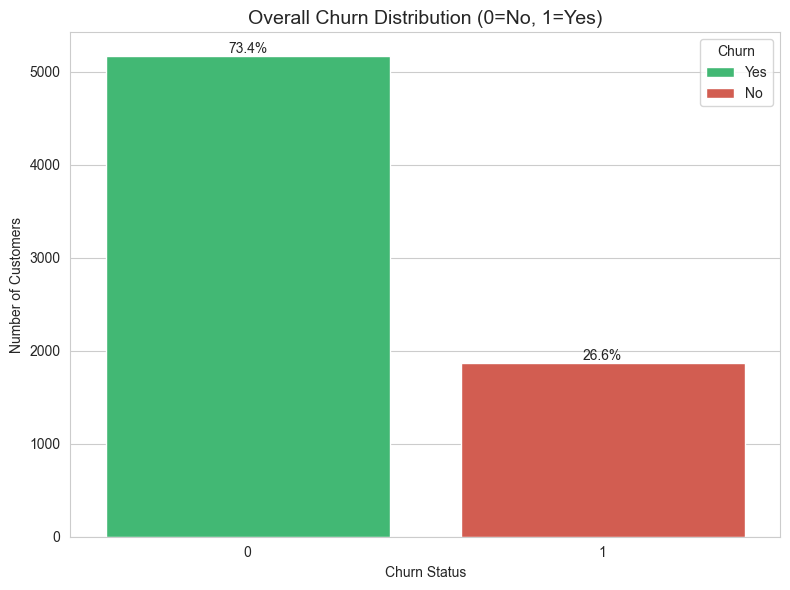

In [74]:
# Create a new figure
plt.figure(figsize=(8, 6))

# Plot the churn distribution
sns.countplot(x='is_churned', data=df, palette=churn_colors)
plt.title('Overall Churn Distribution (0=No, 1=Yes)', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

# Calculate and display percentages
total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.show()

## 📉 Overall Churn Distribution Analysis

This chart illustrates the **overall proportion of churned (1=Yes) versus non-churned (0=No) customers** in the dataset.

* The majority of customers, **73.4%** (labeled '0' for No), have **not churned** and are retained by the telecom company.
* A significant portion, **26.6%** (labeled '1' for Yes), represents customers who **have churned**.

The data indicates that while the company successfully retains most of its customers, the **26.6% churn rate** is substantial and highlights the need for a deeper analysis to identify the factors driving this customer loss.

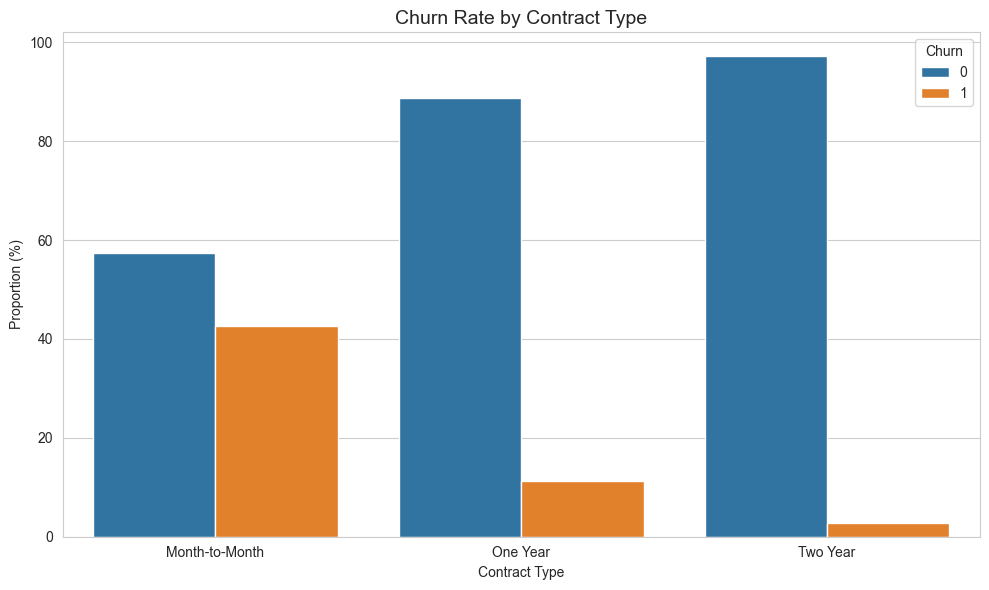

In [ ]:
# Create a new figure
plt.figure(figsize=(10, 6))

# Calculate proportions of churn/no churn within each contract type
contract_churn_prop = df.groupby('contract_type')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='contract_type',
    y='proportion',
    hue='is_churned',
    data=contract_churn_prop
)
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Proportion (%)')

plt.legend(title='Churn')

plt.tight_layout()
plt.show() 

## 📊 Telecom Churn Rate Analysis by Contract Type

This chart clearly shows a strong **inverse relationship** between **contract length** and **churn rate**.

* **Month-to-Month** customers have the highest churn rate, with approximately **57%** leaving the service.
* Customers on a **One Year** contract show a dramatically lower churn rate of around **10%**.
* The lowest churn is seen in the **Two Year** contract group, with a rate of only about **3%**.

This suggests that **longer-term contracts** are highly effective at retaining customers.

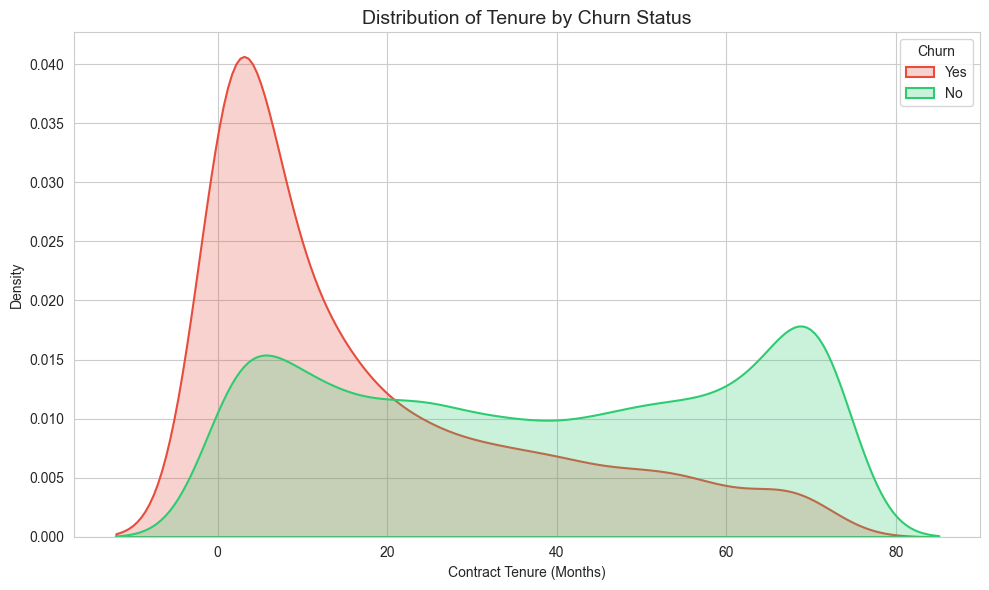

In [96]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='contract_tenure',
    hue='is_churned',
    fill=True,
    common_norm=False,
    palette=churn_colors,
    linewidth=1.5
)
plt.title('Distribution of Tenure by Churn Status', fontsize=14)
plt.xlabel('Contract Tenure (Months)')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

## 🕰️ Distribution of Tenure by Churn Status Analysis

This density plot compares the distribution of **customer tenure (in months)** for those who **churned (Yes/Red)** and those who **did not churn (No/Green)**.

The key observation is the distinct shape of the two distributions:

* **Churned Customers (Red Distribution):** This curve is heavily concentrated on the **left side**, showing a sharp peak at a very **low tenure** (close to 0 months). This indicates that the vast majority of customers who churn do so **very early** in their relationship with the company.
* **Non-Churned Customers (Green Distribution):** This curve shows a broader distribution, with a clear concentration and secondary peak on the **right side** of the graph (around 60 to 75 months). This signifies that customers who are **retained** tend to be those with **long-term tenure**.

In summary, **low tenure is a strong predictor of churn**, while **high tenure is characteristic of loyal, retained customers**.

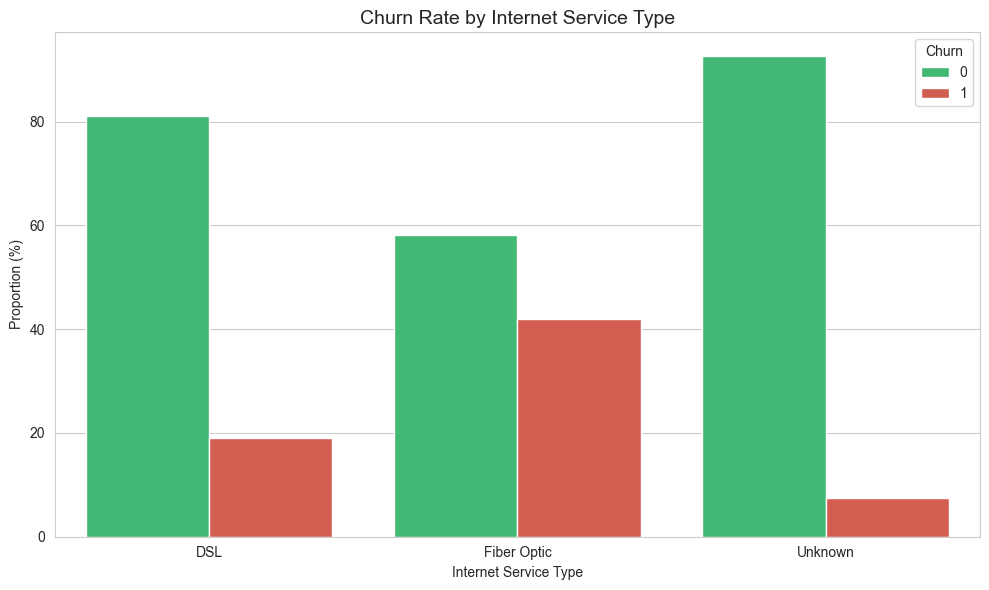

In [ ]:
# --- Churn Rate by Internet Service Type (Proportional Bar Chart) ---

plt.figure(figsize=(10, 6))
service_churn_prop = df.groupby('internet_service')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='internet_service',
    y='proportion',
    hue='is_churned',
    data=service_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Proportion (%)')

plt.legend(title='Churn')

plt.tight_layout()
plt.show()

## 🌐 Churn Rate Analysis by Internet Service Type

This bar chart compares the churn rate across different **Internet Service Types**.

* **Fiber Optic** service has the **highest churn rate** at approximately **42%**. This is a major area of concern for the company.
* **DSL** customers show a moderate churn rate, around **19%**.
* Customers with **No Internet Service** (represented by 'Unknown') have the **lowest churn rate**, at about **8%**, indicating high loyalty in this segment.

The analysis highlights the **Fiber Optic service** as the primary driver of customer loss, suggesting an urgent need for improvement in its quality, pricing, or competitiveness.

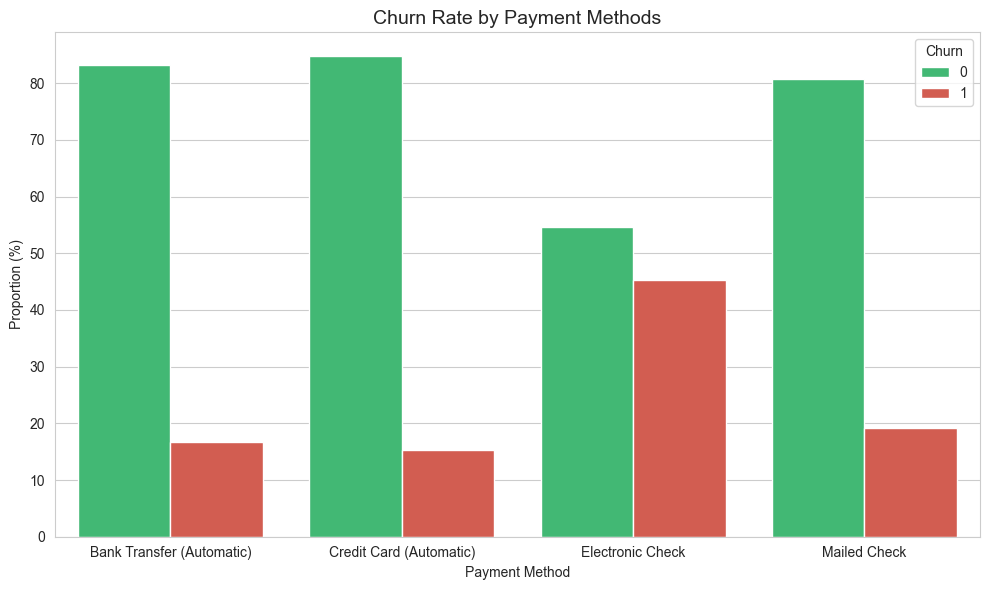

In [ ]:
# ---  Churn Rate by Internet Service Type (Proportional Bar Chart) ---

plt.figure(figsize=(10, 6))
service_churn_prop = df.groupby('payment_method_name')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='payment_method_name',
    y='proportion',
    hue='is_churned',
    data=service_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Payment Methods', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

## 💳 Churn Rate Analysis by Payment Method

This bar chart compares the churn rate across different **Payment Methods**.

* **Electronic Check** is the clear standout, showing the **highest churn rate** at approximately **45%**. This is a major area of concern, suggesting customers using this method are the least loyal.
* **Mailed Check** has a moderate churn rate, around **19%**.
* **Bank Transfer (automatic)** and **Credit Card (automatic)** show the **lowest and best retention rates**, both with churn rates under **16%**.

The analysis strongly suggests a correlation between the **convenience and automation** of payment and customer loyalty. Encouraging customers to switch from Electronic Check to automatic payment methods (Bank Transfer or Credit Card) could be a key retention strategy.

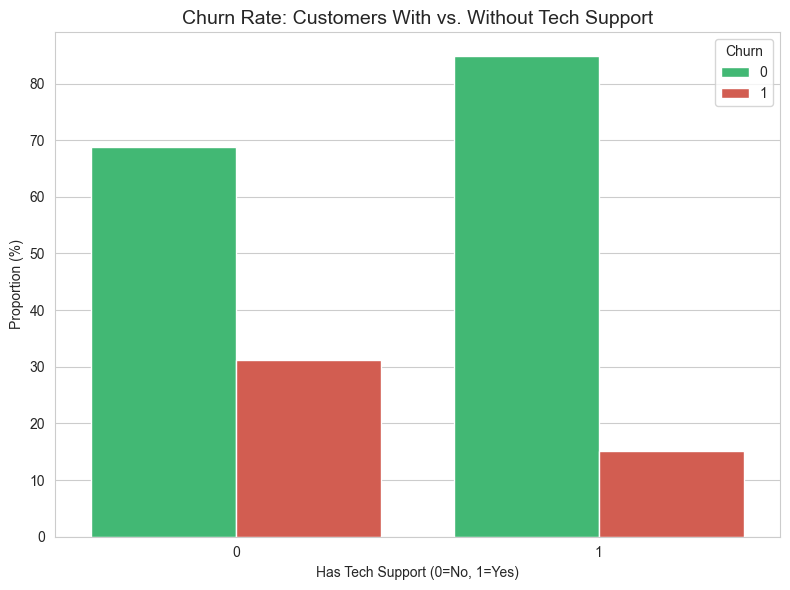

In [93]:
# --- Churn Rate by Tech Support---

plt.figure(figsize=(8, 6))
tech_support_churn_prop = df.groupby('has_tech_support')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='has_tech_support',
    y='proportion',
    hue='is_churned',
    data=tech_support_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate: Customers With vs. Without Tech Support', fontsize=14)
plt.xlabel('Has Tech Support (0=No, 1=Yes)')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## 🛠️ Churn Rate: Customers With vs. Without Tech Support Analysis

This bar chart compares the churn rate (1=Yes) between customers who **have** Tech Support (1) and those who **do not have** Tech Support (0).

* **Customers without Tech Support (0):** This group exhibits a significantly higher churn rate, with approximately **31%** leaving the service.
* **Customers with Tech Support (1):** This group has a much lower churn rate, at about **15%**.

The analysis strongly suggests that **offering and utilizing Tech Support acts as a strong retention mechanism**. Customers who have access to or use Tech Support are **more than twice as likely to be retained** compared to those who do not.


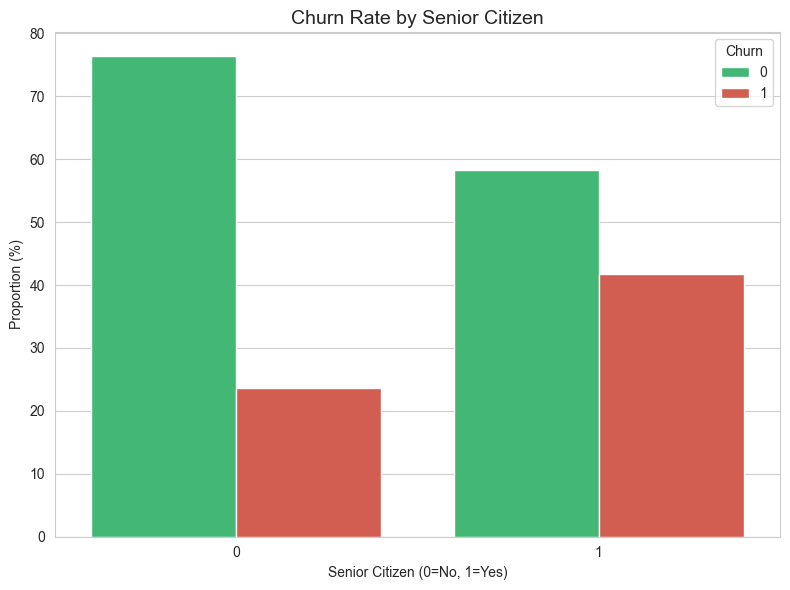

In [94]:
# --- Churn Rate by Tech Support---

plt.figure(figsize=(8, 6))
tech_support_churn_prop = df.groupby('is_senior_citizen')['is_churned'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

sns.barplot(
    x='is_senior_citizen',
    y='proportion',
    hue='is_churned',
    data=tech_support_churn_prop,
    palette=churn_colors
)
plt.title('Churn Rate by Senior Citizen', fontsize=14)
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Proportion (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## 👵 Churn Rate Analysis by Senior Citizen Status

This bar chart compares the churn rate (1=Yes) for customers who **are Senior Citizens** (1) versus those who **are not Senior Citizens** (0).

* **Non-Senior Citizens (0):** This large group shows a moderate churn rate, with approximately **24%** of customers leaving the service.
* **Senior Citizens (1):** This group exhibits a significantly **higher churn rate**, with around **42%** of customers churning.

The analysis indicates that **Senior Citizens are disproportionately likely to churn** compared to younger customers.

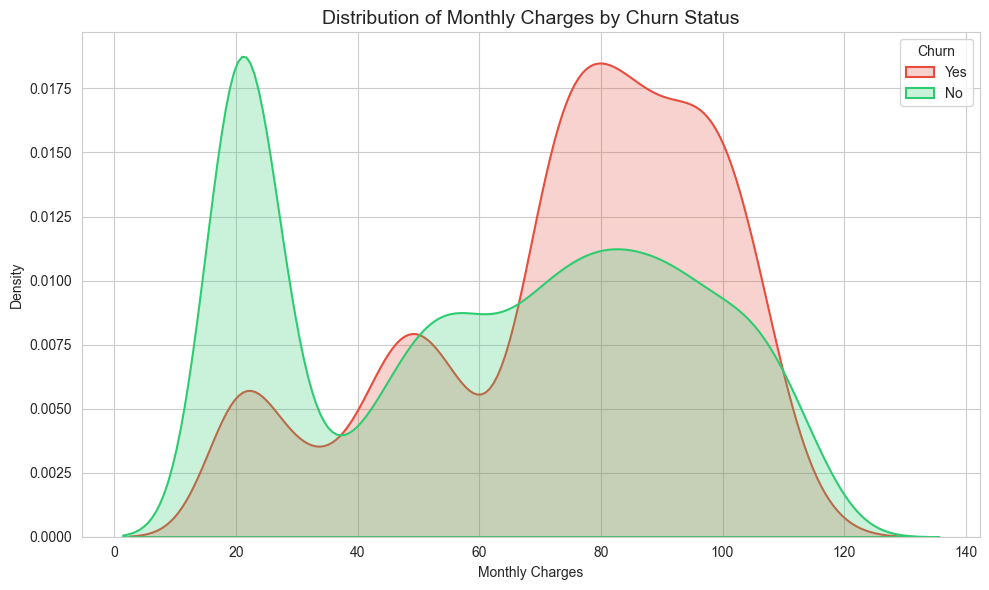

In [95]:
# --- Distribution of Monthly Charges by Churn Status ---

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='monthly_charges',
    hue='is_churned',
    fill=True,
    common_norm=False,
    palette=churn_colors,
    linewidth=1.5
)
plt.title('Distribution of Monthly Charges by Churn Status', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

## 💰 Distribution of Monthly Charges by Churn Status Analysis

This density plot compares the distribution of **Monthly Charges** for customers who **churned (Yes/Red)** versus those who **did not churn (No/Green)**.

The key finding is the clear difference in the areas of peak density:

* **Non-Churned Customers (Green Distribution):** This curve shows a dominant peak at **low monthly charges** (around 20). This indicates that customers with **low-cost plans** are much more likely to be retained.
* **Churned Customers (Red Distribution):** This curve shows a clear, significant peak at **high monthly charges** (around 80 to 100). This indicates that customers paying **high monthly fees** are the most likely to churn.

In summary, **high monthly charges are strongly correlated with customer attrition**, suggesting that pricing and value perception are major factors driving customers away.

# Data Cleaning